In [1]:
from __future__ import annotations

import pickle

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import manifold_dynamics.neural_utils as nu
import manifold_dynamics.paths as pth
import manifold_dynamics.tuning_utils as tut
import visionlab_utils.storage as vst

In [2]:
# ROI name, should be 3 parts (index.label.category)
target = "19.Unknown.F"
target_parts = target.split(".")
roi_label = f"{int(target_parts[0]):02d}.{target_parts[1]}.{target_parts[2]}"

# load in multi-session ROI data, binned to PSTH
raster_4d = nu.significant_trial_raster(target, alpha=0.05, bin_size_ms=20)

# get top-k value for ROI
topk_local = vst.fetch(f"{pth.OTHERS}/topk_vals.pkl")
with open(topk_local, "rb") as f:
    topk_vals = pickle.load(f)
top_k = int(topk_vals[roi_label]["k"])

print(f"Resolved ROI target: {target}")
print(f"Using top-k = {top_k}")
print(f"Raster shape after binning {raster_4d.shape}")

raster_3d = np.nanmean(raster_4d, axis=3)
scores = tut.rank_images_by_response(raster_3d)
idx_topk = scores[:top_k]

/Users/anmarmarvi/Desktop/HVRD/workspace/manifold-dynamics/.venv/lib/python3.13/site-packages/fsspec/registry.py:301: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


Resolved ROI target: 19.Unknown.F
Using top-k = 30
Raster shape after binning (236, 450, 1072, 7)


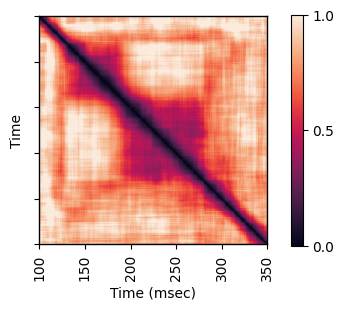

In [13]:
R, rdv = tut.tuning_rdm(raster_3d, indices=idx_topk, tstart=100, tend=350)

use_cbar = True
fig = plt.figure(figsize=(3 + 0.4 * use_cbar, 3))
if use_cbar:
    gs = fig.add_gridspec(1, 2, width_ratios=[20, 1])
    ax = fig.add_subplot(gs[0, 0])
    cax = fig.add_subplot(gs[0, 1])
else:
    gs = fig.add_gridspec(1, 1)
    ax = fig.add_subplot(gs[0, 0])
    cax = None

customp = sns.color_palette('rocket', as_cmap=True)
vmin, vmax = 0, 1

im = sns.heatmap(
    R,
    vmax=vmax,
    vmin=vmin,
    cmap=customp,
    square=True,
    rasterized=True,
    ax=ax,
    cbar=False,
)

if use_cbar:
    fig.colorbar(
        im.collections[0],
        cax=cax,
        ticks=[0, 0.5, 1],
    )

ax.set_xticks(np.arange(0, 300, 50))
ax.set_xticklabels(np.arange(0, 300, 50) + 100)
ax.set_yticks(np.arange(0, 300, 50))

ax.set_xlabel('Time (msec)')
ax.set_ylabel('Time')

sns.despine(ax=ax, trim=True, offset=5)